# RAG Evaluation Metrics — Exploration

Loads the latest Langfuse export from `local/metric-export/` and produces basic plots.

**Run the export first:**
```bash
python analysis/langfuse_export.py --session-id <your_session_id>
```

In [22]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

EXPORT_DIR = Path("../local/metric-export")


def load_latest(prefix: str = "*langfuse_export*") -> pd.DataFrame:
    files = sorted(EXPORT_DIR.glob(f"{prefix}.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files matching {EXPORT_DIR / prefix}")
    path = files[-1]
    print(f"Loading: {path.name}")
    return pd.read_parquet(path)


df = load_latest(prefix="2026-03-04_18-34_langfuse_export_multilingual-e5-small_q4__ministral_3_3B_q4")
print(f"Shape: {df.shape}")
df.head()

Loading: 2026-03-04_18-34_langfuse_export_multilingual-e5-small_q4__ministral_3_3B_q4.parquet
Shape: (132, 35)


,trace_id,session_id,observation_id,start_time,end_time,latency_ms,run_id,claim_id,langfuse_observation_type,latency_ttft_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Correctness,score_Context Recall,score_Evaluate Hallucination V2
0,fe0589f980ec26becbb625f59add0856,multilingual-e5-small_q4__ministral_3_3B_q4,49c7977164bd51f6,2026-03-04 17:50:49.379000+00:00,2026-03-04 17:50:50.672000+00:00,1293.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_92,generation,292.566306,...,0.000000,0.000000,1290.621000,7336.578125,19.35,10895360,0,0.10,1.000000e+00,0.0
1,e1b85b669f0c2b0cb92b1f739ce734b2,multilingual-e5-small_q4__ministral_3_3B_q4,7b4f2ef379efe3e1,2026-03-04 17:50:48.819000+00:00,2026-03-04 17:50:49.379000+00:00,560.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_403,generation,47.638400,...,0.166667,0.200000,555.620458,7332.531250,0.00,2834432,0,0.15,1.000000e+00,0.1
2,e065ebcd0b5659733b767cb42517baa9,multilingual-e5-small_q4__ministral_3_3B_q4,9509de51d58d7e2d,2026-03-04 17:50:46.380000+00:00,2026-03-04 17:50:48.819000+00:00,2439.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_276,generation,61.229333,...,0.166667,0.333333,2429.335458,7261.703125,24.00,5210112,32768,0.55,4.000000e-16,0.3
3,5397901369dfeeea7f9cd6835794f9e2,multilingual-e5-small_q4__ministral_3_3B_q4,4ffb396628a33612,2026-03-04 17:50:44.434000+00:00,2026-03-04 17:50:46.380000+00:00,1946.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_347,generation,1199.352086,...,0.500000,1.000000,1939.026125,7267.968750,17.75,9617408,0,0.60,1.000000e+00,0.1
4,9e28501ef1075dac7f2e459518aade8f,multilingual-e5-small_q4__ministral_3_3B_q4,ff5fc5a78e05abf1,2026-03-04 17:50:42.873000+00:00,2026-03-04 17:50:44.433000+00:00,1560.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_82,generation,46.480755,...,0.000000,0.000000,1548.347625,7374.234375,16.75,4096000,32768,0.10,1.000000e+00,0.0


## Summary statistics

In [23]:
metric_cols = [
    c for c in df.columns
    if any(c.startswith(p) for p in ("metrics_", "latency_", "generation_", "hardware_", "score_"))
]
df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
latency_ms,132.0,2.558652e+03,8.966562e+03,324.000000,1.229250e+03,1.660000e+03,2.176750e+03,1.043320e+05
latency_ttft_ms,132.0,1.210165e+03,8.693449e+03,42.120667,5.624876e+01,3.754820e+02,6.590337e+02,1.002313e+05
latency_llm_generation_latency_ms,132.0,1.051340e+03,7.330863e+02,41.219000,5.266825e+02,9.561970e+02,1.348916e+03,4.303322e+03
latency_prompt_ms,132.0,1.188631e+03,8.689096e+03,24.634000,3.479800e+01,3.529425e+02,6.354830e+02,1.001604e+05
latency_predicted_ms,132.0,1.051340e+03,7.330863e+02,41.219000,5.266825e+02,9.561970e+02,1.348916e+03,4.303322e+03
latency_predicted_per_token_ms,132.0,2.153413e+01,4.916755e+00,13.739667,2.051523e+01,2.100609e+01,2.192542e+01,7.091137e+01
generation_prompt_tokens,132.0,3.411515e+02,1.398395e+02,200.000000,2.310000e+02,2.895000e+02,4.080000e+02,7.340000e+02
generation_completion_tokens,132.0,4.737121e+01,3.044916e+01,3.000000,2.550000e+01,4.600000e+01,6.200000e+01,2.000000e+02
generation_tokens_per_second,132.0,4.760949e+01,6.426036e+00,14.102111,4.560916e+01,4.760549e+01,4.874428e+01,7.278197e+01
latency_retrieval_latency_ms,132.0,6.258261e+01,5.129328e+01,7.469875,1.894054e+01,4.295844e+01,9.814694e+01,2.509171e+02


## Per-run comparison

In [24]:
if "run_id" in df.columns:
    agg_cols = [c for c in metric_cols if df[c].dtype in ("float64", "float32", "int64")]
    display(df.groupby("run_id")[agg_cols].mean().round(3))

,latency_ms,latency_ttft_ms,latency_llm_generation_latency_ms,latency_prompt_ms,latency_predicted_ms,latency_predicted_per_token_ms,generation_prompt_tokens,generation_completion_tokens,generation_tokens_per_second,latency_retrieval_latency_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Correctness,score_Context Recall,score_Evaluate Hallucination V2
run_id,,,,,,,,,,,,,,,,,,,,,
multilingual-e5-small_q4__ministral_3_3B_q4,2558.652,1210.165,1051.34,1188.631,1051.34,21.534,341.152,47.371,47.609,62.583,...,0.149,0.285,1799.559,7548.4,26.713,3.706520e+07,291684.848,0.302,1.492,0.173


## Latency distribution

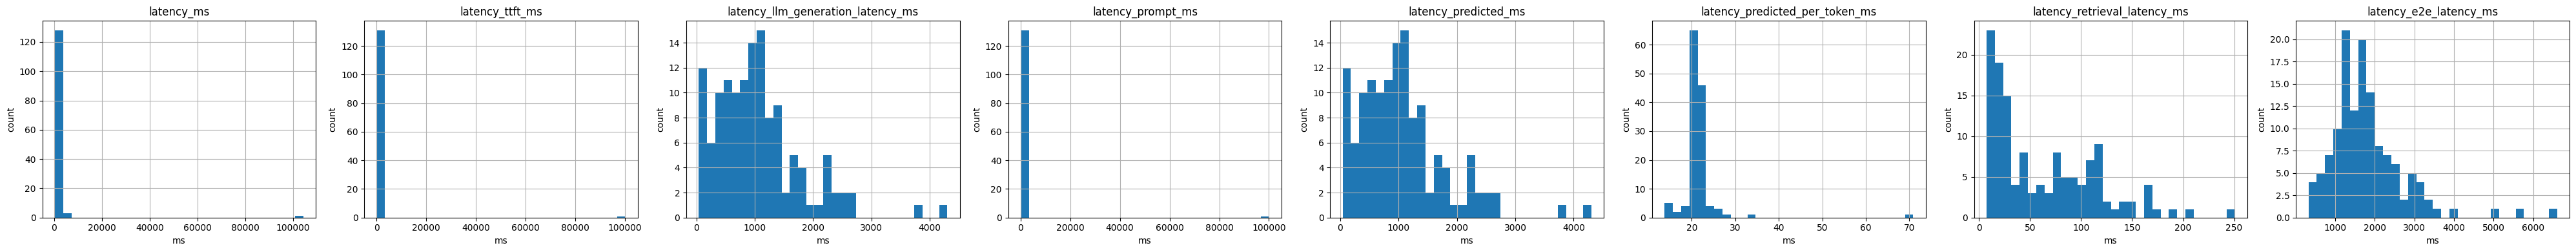

In [28]:
latency_cols = [c for c in df.columns if "latency" in c]

fig, axes = plt.subplots(1, len(latency_cols), figsize=(5*len(latency_cols), 4))
if len(latency_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, latency_cols):
    df[col].dropna().hist(bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("ms")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

## Retrieval quality: Recall vs MRR

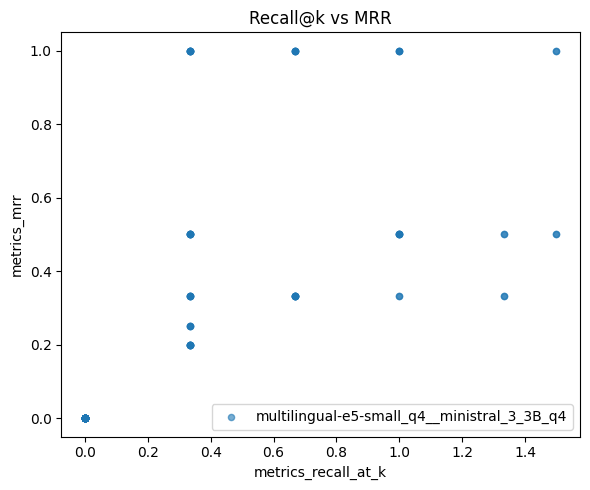

In [29]:
recall_col = next((c for c in df.columns if "recall" in c), None)
mrr_col = next((c for c in df.columns if "mrr" in c), None)

if recall_col and mrr_col:
    fig, ax = plt.subplots(figsize=(6, 5))
    groups = df.groupby("run_id") if "run_id" in df.columns else [("all", df)]
    for label, group in groups:
        ax.scatter(group[recall_col], group[mrr_col], label=label, alpha=0.6, s=20)
    ax.set_xlabel(recall_col)
    ax.set_ylabel(mrr_col)
    ax.set_title("Recall@k vs MRR")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("recall or mrr columns not found — skipping scatter plot")

## Langfuse scores (if present)

,count,mean,std,min,25%,50%,75%,max
score_Correctness,132.0,0.301515,0.295574,0.0,0.1,0.2,0.5,1.0
score_Context Recall,132.0,1.491667,4.413101,0.0,1.0,1.0,1.0,50.0
score_Evaluate Hallucination V2,132.0,0.173030,0.295728,0.0,0.0,0.0,0.2,1.0


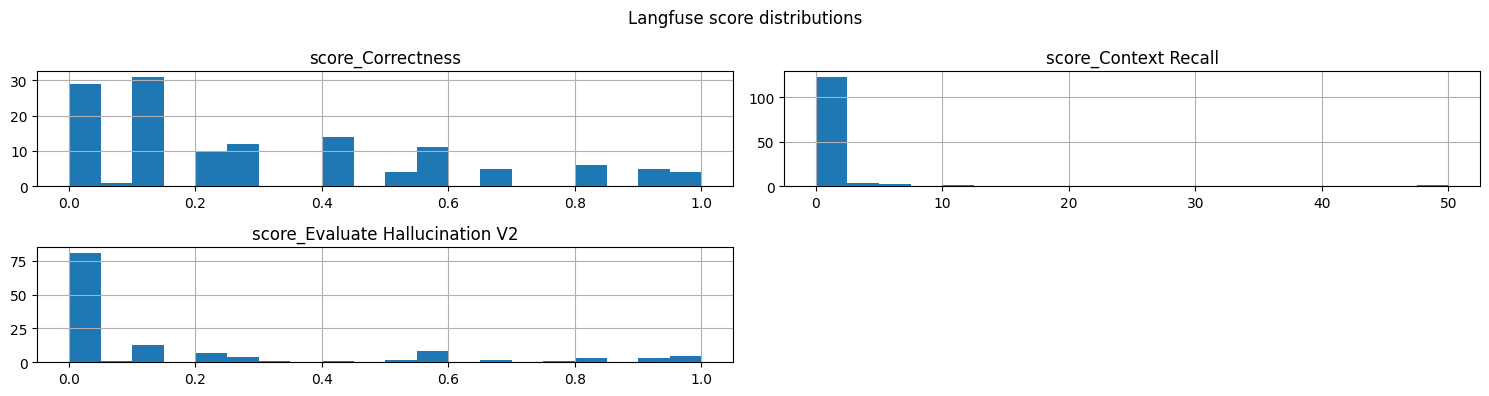

In [30]:
score_cols = [c for c in df.columns if c.startswith("score_")]
if score_cols:
    display(df[score_cols].describe().T)
    df[score_cols].hist(bins=20, figsize=(5 * len(score_cols), 4))
    plt.suptitle("Langfuse score distributions")
    plt.tight_layout()
    plt.show()
else:
    print("No score_ columns found — no Langfuse scores were exported")

## Generation throughput

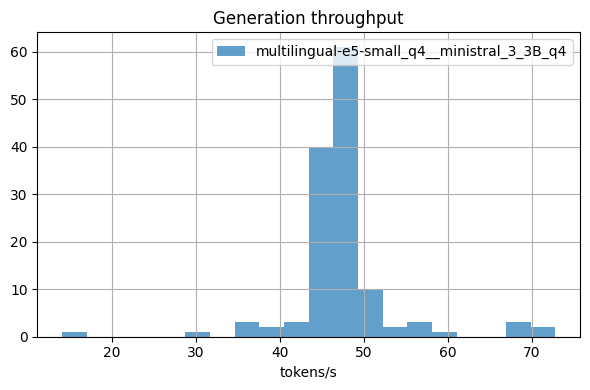

In [31]:
tps_col = next((c for c in df.columns if "tokens_per_second" in c), None)
if tps_col:
    fig, ax = plt.subplots(figsize=(6, 4))
    if "run_id" in df.columns:
        for label, group in df.groupby("run_id"):
            group[tps_col].dropna().hist(bins=20, ax=ax, alpha=0.7, label=label)
        ax.legend()
    else:
        df[tps_col].dropna().hist(bins=20, ax=ax)
    ax.set_xlabel("tokens/s")
    ax.set_title("Generation throughput")
    plt.tight_layout()
    plt.show()